# 04 — Unsupervised signature plots

This notebook:
- loads the fitted signature activities,
- creates overview heatmaps,
- merges activities with smoking annotation,
- creates smoking-group heatmaps,
- creates the SBS4 boxplot with individual points.


In [40]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)

def map_smoking_label(value):
    value = str(value).strip().lower()

    if value in ["", "nan", "not reported", "unknown"]:
        return "Unknown"
    elif "never" in value or "lifelong" in value or "non-smoker" in value or "nonsmoker" in value:
        return "Never"
    elif "former" in value or "reformed" in value:
        return "Former"
    elif "current" in value:
        return "Current"
    else:
        return "Unknown"

## 1. Define paths


In [41]:
activities_path = (
    PROJECT_ROOT
    / "results"
    / "LUAD_sig_output"
    / "Assignment_Solution"
    / "Activities"
    / "Assignment_Solution_Activities.txt"
)

clinical_path = PROJECT_ROOT / "data" / "clinical_exposure_merged.tsv"
plots_dir = PROJECT_ROOT / "plots"
clinical_plots_dir = plots_dir / "supervised_heatmaps"

clinical_plots_dir.mkdir(parents=True, exist_ok=True)

display(
    pd.DataFrame({
        "file": ["activities", "clinical merged"],
        "path": [activities_path, clinical_path],
    })
)

,file,path
0,activities,/Users/michaljendrusak/PycharmProjects/tcga-lu...
1,clinical merged,/Users/michaljendrusak/PycharmProjects/tcga-lu...


## 2. Load the fitted activities


In [42]:
activities_df = pd.read_csv(activities_path, sep="\t", index_col=0)

sbs_cols = [col for col in activities_df.columns if col.startswith("SBS") and col[3:].isdigit()]
sbs_cols = sorted(sbs_cols, key=lambda x: int(x[3:]))

activities_df = activities_df[sbs_cols].copy()
activities_df = activities_df.apply(pd.to_numeric, errors="coerce").fillna(0)
activities_df = activities_df.div(activities_df.sum(axis=1), axis=0)

display(
    pd.DataFrame({
        "rows": [activities_df.shape[0]],
        "columns": [activities_df.shape[1]],
    })
)

display(activities_df.iloc[:5, :10])

,rows,columns
0,616,71


,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS8,SBS9,SBS11,SBS12
Samples,,,,,,,,,,
TCGA-05-4244-01A-01D-1105-08,0.018182,0.000000,0.0,0.681818,0.213636,0.086364,0.0,0.0,0.0,0.0
TCGA-05-4249-01A-01D-1105-08,0.021407,0.000000,0.0,0.614679,0.262997,0.000000,0.0,0.0,0.0,0.0
TCGA-05-4250-01A-01D-1105-08,0.023684,0.055263,0.0,0.544737,0.192105,0.000000,0.0,0.0,0.0,0.0
TCGA-05-4382-01A-01D-1931-08,0.025126,0.054160,0.0,0.841988,0.036293,0.000000,0.0,0.0,0.0,0.0
TCGA-05-4384-01A-01D-1753-08,0.000000,0.000000,0.0,0.573529,0.323529,0.000000,0.0,0.0,0.0,0.0


## 3. Create all sample heatmap


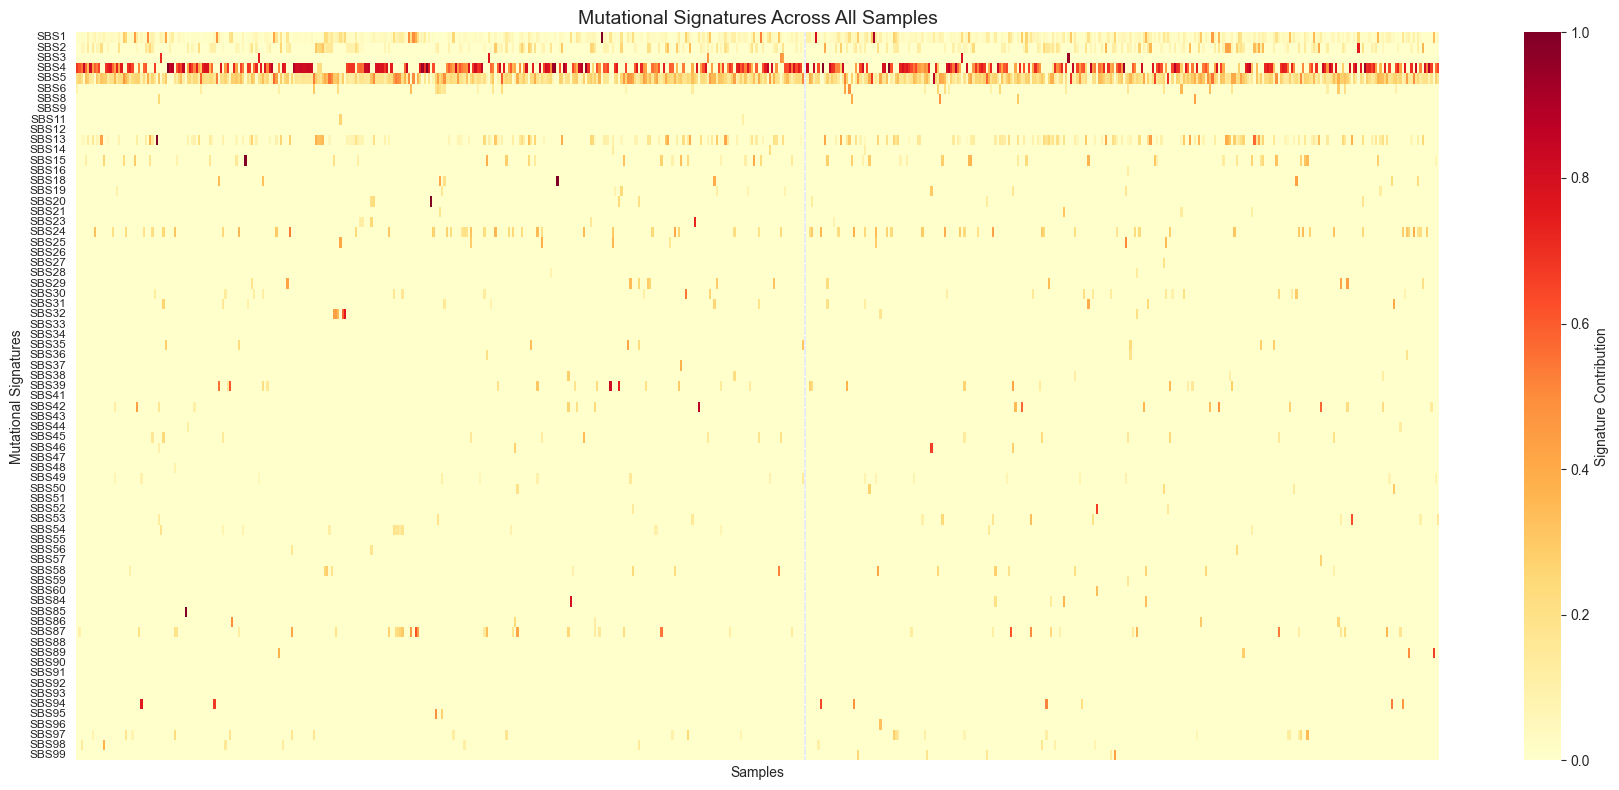

In [43]:
plt.figure(figsize=(18, 8))
ax = sns.heatmap(
    activities_df.T,
    cmap="YlOrRd",
    linewidths=0,
    xticklabels=False,
    yticklabels=True,
    cbar_kws={"label": "Signature Contribution"},
    vmin=0, vmax=1
)

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8.5)

plt.title("Mutational Signatures Across All Samples", fontsize=14)
plt.xlabel("Samples")
plt.ylabel("Mutational Signatures")
plt.tight_layout()

plt.savefig(plots_dir / "heatmap_all_samples.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Load the merged clinical table and prepare smoking groups


In [44]:
clinical_df = pd.read_csv(clinical_path, sep="\t")

activities_with_id = activities_df.copy()
activities_with_id["Patient_ID"] = activities_with_id.index.to_series().str.split("_").str[0].str[:12]

clinical_df["Patient_ID"] = clinical_df["cases.submitter_id"].astype(str).str[:12]

merged_df = pd.merge(
    activities_with_id,
    clinical_df,
    on="Patient_ID",
    how="inner"
)

merged_df["Smoking_Category"] = merged_df["exposures.tobacco_smoking_status"].map(map_smoking_label)

display(
    pd.DataFrame({
        "rows": [merged_df.shape[0]],
        "columns": [merged_df.shape[1]],
        "unique_patients": [merged_df["Patient_ID"].nunique()],
    })
)

display(
    merged_df["Smoking_Category"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "Smoking_Category", "Smoking_Category": "n"})
)

display(merged_df.iloc[:5, :12])

,rows,columns,unique_patients
0,552,80,493


,n,count
0,Former,348
1,Current,128
2,Never,76


,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS8,SBS9,SBS11,SBS12,SBS13,SBS14
0,0.018182,0.000000,0.0,0.681818,0.213636,0.086364,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.021407,0.000000,0.0,0.614679,0.262997,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.023684,0.055263,0.0,0.544737,0.192105,0.000000,0.0,0.0,0.0,0.0,0.042105,0.0
3,0.025126,0.054160,0.0,0.841988,0.036293,0.000000,0.0,0.0,0.0,0.0,0.042434,0.0
4,0.000000,0.000000,0.0,0.573529,0.323529,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0


## 6. Aggregate to patient level


In [45]:
patient_signatures = merged_df.groupby("Patient_ID")[sbs_cols].mean().reset_index()

patient_info = (
    merged_df[["Patient_ID", "Smoking_Category", "exposures.pack_years_smoked"]]
    .drop_duplicates(subset=["Patient_ID"])
)

patient_level = pd.merge(patient_signatures, patient_info, on="Patient_ID", how="left")

patient_level = patient_level[
    patient_level["Smoking_Category"].isin(["Never", "Former", "Current"])
].copy()

patient_counts = (
    patient_level["Smoking_Category"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "Smoking_Category", "Smoking_Category": "n_patients"})
)

display(patient_counts)
display(patient_level.iloc[:5, :12])

,n_patients,count
0,Former,305
1,Current,119
2,Never,69


,Patient_ID,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS8,SBS9,SBS11,SBS12,SBS13
0,TCGA-05-4244,0.018182,0.000000,0.0,0.681818,0.213636,0.086364,0.0,0.0,0.0,0.0,0.000000
1,TCGA-05-4249,0.021407,0.000000,0.0,0.614679,0.262997,0.000000,0.0,0.0,0.0,0.0,0.000000
2,TCGA-05-4250,0.023684,0.055263,0.0,0.544737,0.192105,0.000000,0.0,0.0,0.0,0.0,0.042105
3,TCGA-05-4382,0.025126,0.054160,0.0,0.841988,0.036293,0.000000,0.0,0.0,0.0,0.0,0.042434
4,TCGA-05-4384,0.000000,0.000000,0.0,0.573529,0.323529,0.000000,0.0,0.0,0.0,0.0,0.000000


## 7. Create one heatmap for each smoking group


,Smoking_Category,n_patients
0,Never,68


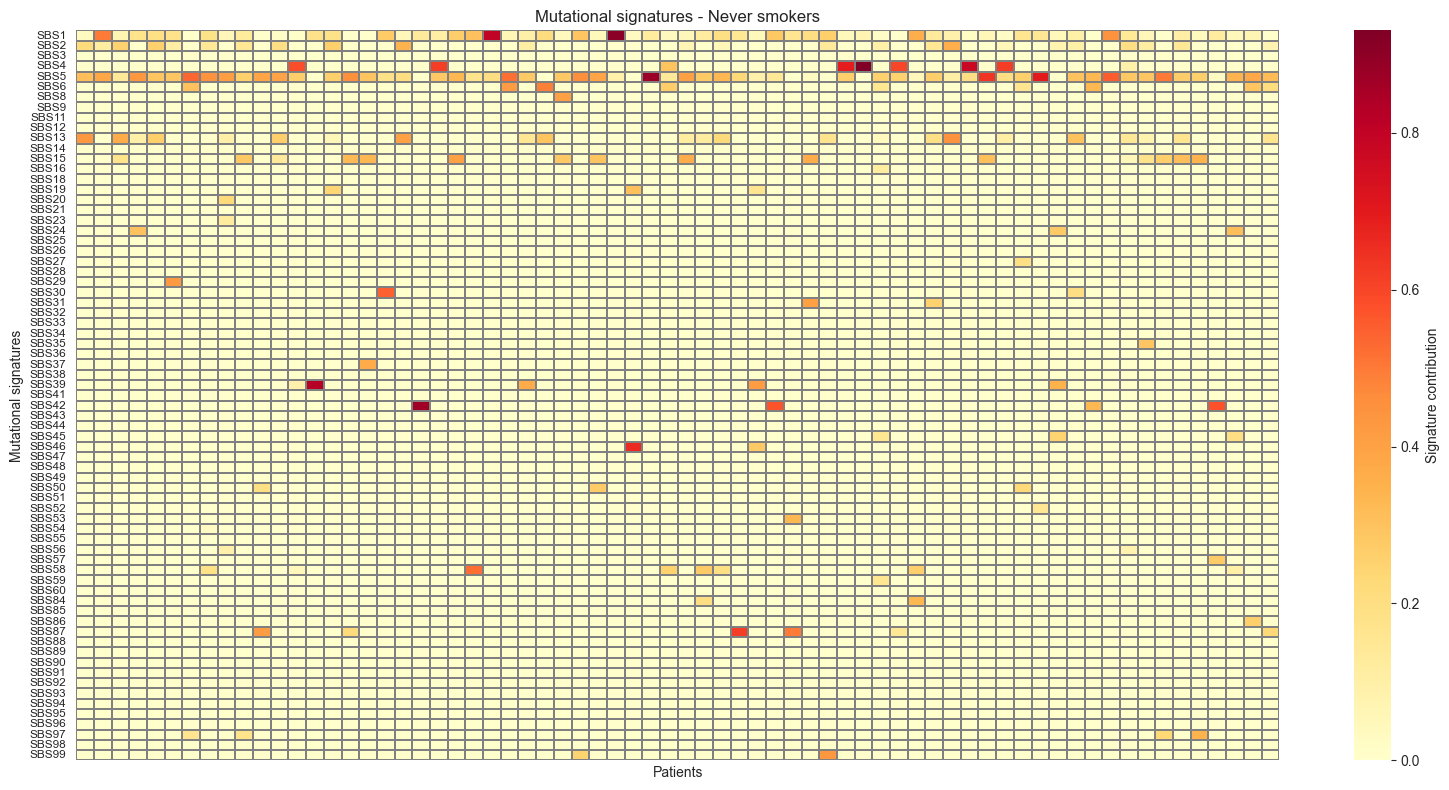

,Smoking_Category,n_patients
0,Former,305


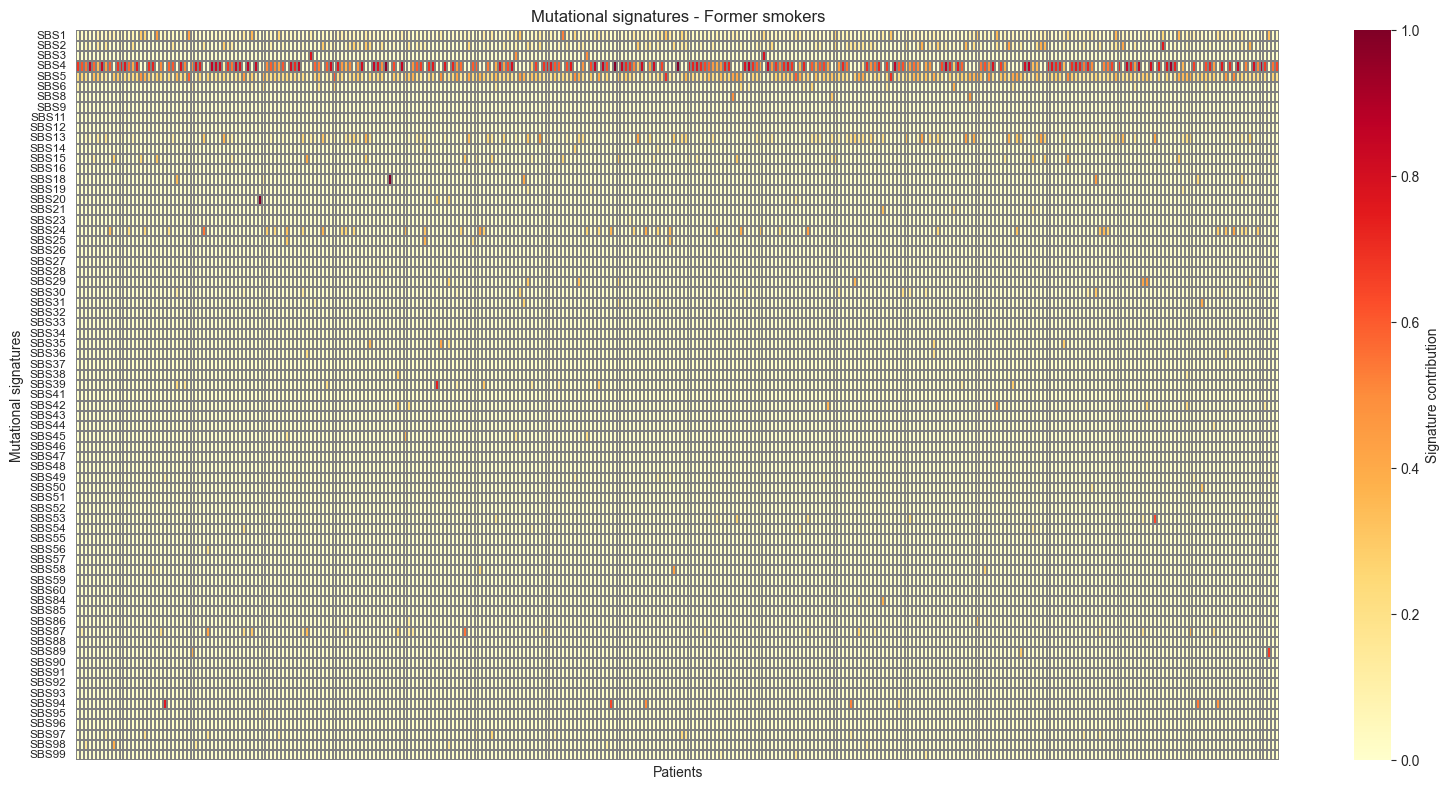

,Smoking_Category,n_patients
0,Current,119


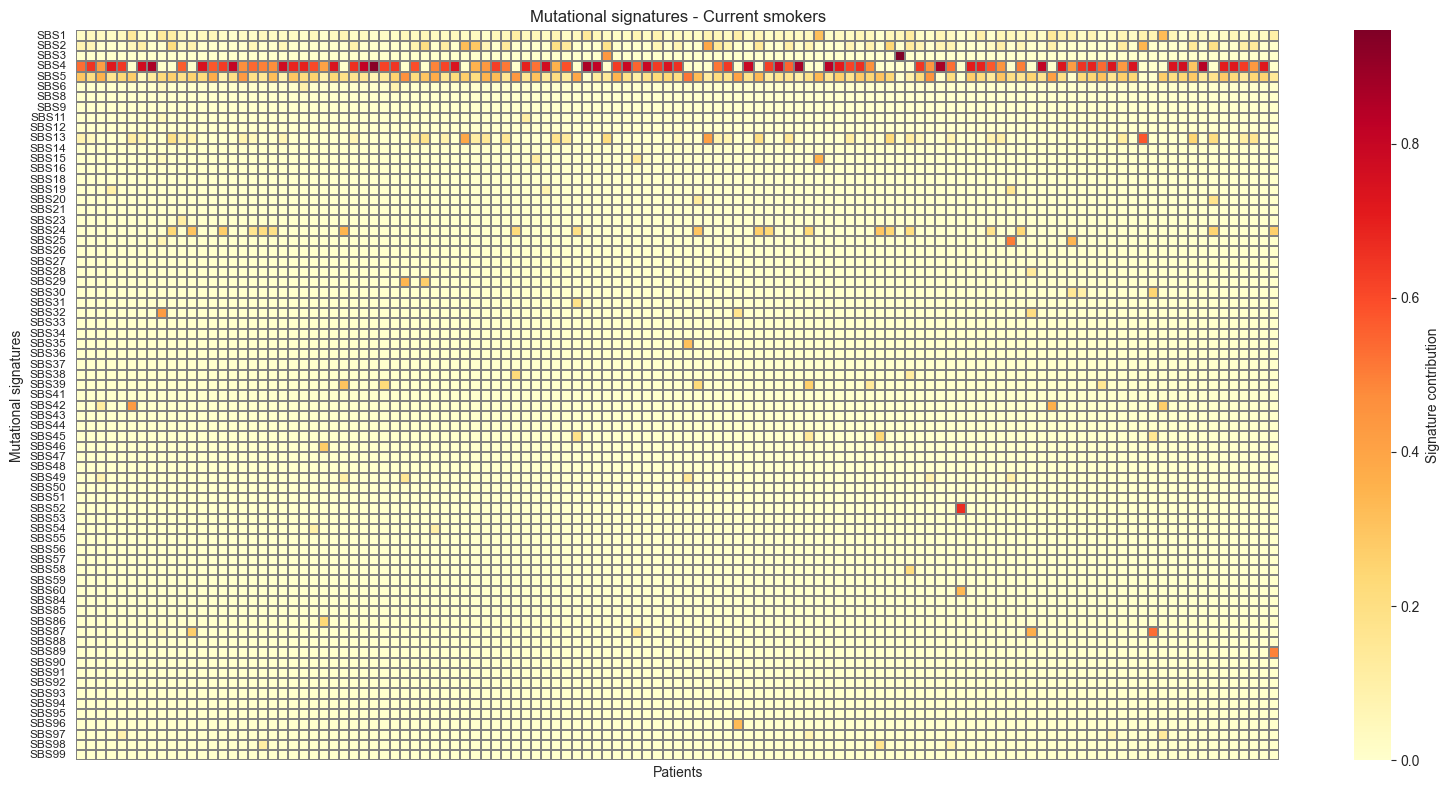

In [46]:
for category in ["Never", "Former", "Current"]:
    subset = patient_level[patient_level["Smoking_Category"] == category]

    if subset.empty:
        continue

    heatmap_data = subset[sbs_cols].T
    heatmap_data = heatmap_data.loc[:, heatmap_data.sum(axis=0) > 0]

    display(
        pd.DataFrame({
            "Smoking_Category": [category],
            "n_patients": [heatmap_data.shape[1]],
        })
    )

    plt.figure(figsize=(16, 8))
    ax = sns.heatmap(
        heatmap_data,
        cmap="YlOrRd",
        linewidths=0.2,
        linecolor="gray",
        cbar_kws={"label": "Signature contribution"},
        xticklabels=False,
        yticklabels=True,
    )

    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8.5)

    plt.title(f"Mutational signatures - {category} smokers")
    plt.xlabel("Patients")
    plt.ylabel("Mutational signatures")
    plt.tight_layout()

    plt.savefig(clinical_plots_dir / f"heatmap_{category}.png", dpi=300, bbox_inches="tight")
    plt.show()

## 8. Create the SBS4 boxplot with individual points


,Smoking_Category,n_for_plot
0,Former,305
1,Current,119
2,Never,68


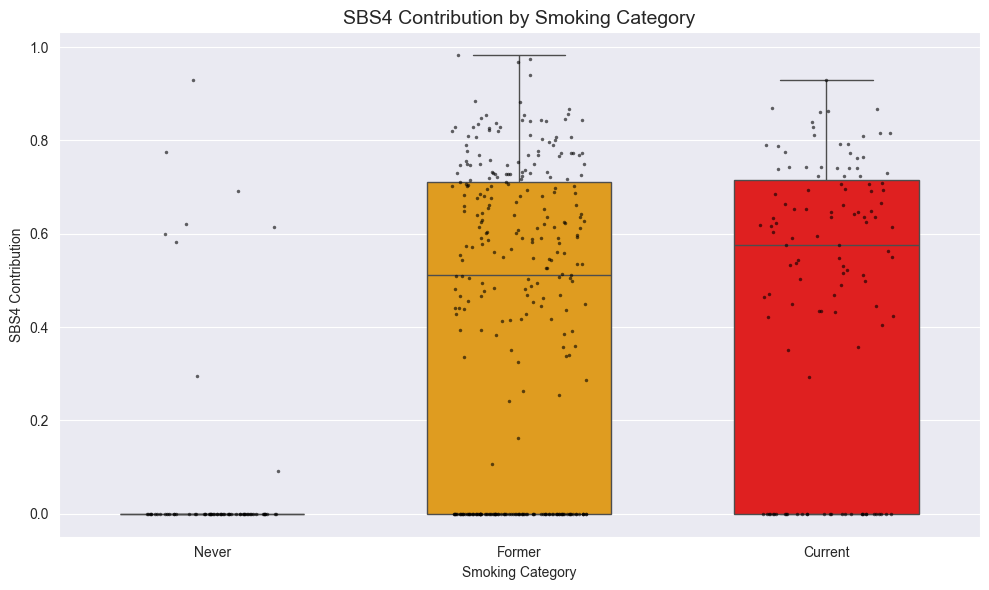

In [47]:
plot_df = patient_level.dropna(subset=["SBS4"]).copy()

display(
    plot_df["Smoking_Category"]
    .value_counts()
    .rename_axis("Smoking_Category")
    .reset_index(name="n_for_plot")
)

order = ["Never", "Former", "Current"]
palette = {
    "Never": "lightgreen",
    "Former": "orange",
    "Current": "red",
}

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x="Smoking_Category",
    y="SBS4",
    hue="Smoking_Category",
    order=order,
    palette=palette,
    width=0.6,
    fliersize=0,
    dodge=False,
    legend=False,
)

sns.stripplot(
    data=plot_df,
    x="Smoking_Category",
    y="SBS4",
    order=order,
    jitter=0.22,
    size=2.5,
    alpha=0.6,
    color="black",
)

plt.title("SBS4 Contribution by Smoking Category", fontsize=14)
plt.xlabel("Smoking Category")
plt.ylabel("SBS4 Contribution")
plt.tight_layout()

plt.savefig(plots_dir / "SBS4_boxplot_stripplot_clean.png", dpi=300, bbox_inches="tight")
plt.show()